# Ejercicio 1

Construir elementos estructurantes

In [360]:
# Configuración Inicial y Función de Error
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets
import scipy.ndimage as ndimage # Útil para filtros no lineales

def aplicar_ruido_salpi(img, ratio):
    # generar coordenadas aleatorias en la imagen
    total_pixeles = img.shape[0] * img.shape[1]
    total_pixeles_ruidosos = int(total_pixeles * ratio)
    total_pixeles_ruidosos = (total_pixeles_ruidosos // 2) * 2  # forzar que sea par

    pixeles_ruidosos = np.random.choice(total_pixeles, total_pixeles_ruidosos, replace=False)

    # la mitad de las coordenadas seran blancos (sal) y la otra mitad negros (pimienta)
    img_ruidosa = img.copy()
    img_ruidosa.ravel()[pixeles_ruidosos[:total_pixeles_ruidosos//2]] = 255 # blancos
    img_ruidosa.ravel()[pixeles_ruidosos[total_pixeles_ruidosos//2:]] = 0 # negros

    return img_ruidosa

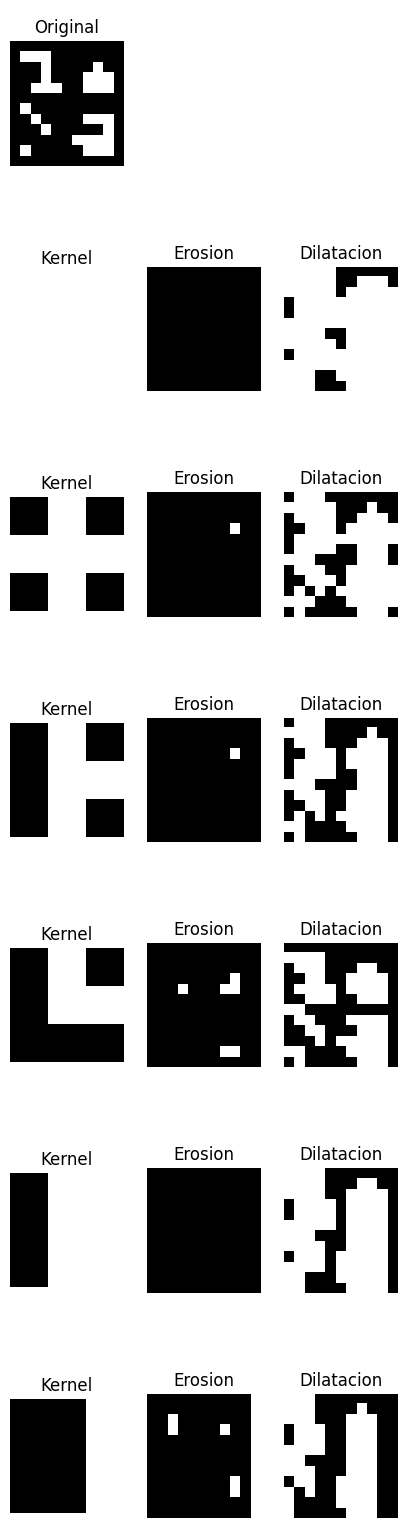

In [361]:
kernels = [
    255*np.array([
        [1,1,1],
        [1,1,1],
        [1,1,1],
    ], dtype=np.uint8),
    255*np.array([
        [0,1,0],
        [1,1,1],
        [0,1,0],
    ], dtype=np.uint8),
    255*np.array([
        [0,1,0],
        [0,1,1],
        [0,1,0],
    ], dtype=np.uint8),
    255*np.array([
        [0,1,0],
        [0,1,1],
        [0,0,0],
    ], dtype=np.uint8),
    255*np.array([
        [0,1,1],
        [0,1,1],
        [0,1,1],
    ], dtype=np.uint8),
    255*np.array([
        [0,0,1],
        [0,0,1],
        [0,0,1],
    ], dtype=np.uint8)
]

img = 255*np.array([
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0,0,1,0,0],
    [0,0,0,1,0,0,0,1,1,1,0],
    [0,0,1,1,1,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0,0],
    [0,0,1,0,0,0,0,1,1,1,0],
    [0,0,0,1,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,1,1,1,1,0],
    [0,1,0,0,0,0,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0],
], dtype=np.uint8)

fig, ax = plt.subplots(7, 3, figsize=(5, 20))

ax[0,0].imshow(img, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title(f"Original"); ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')

for i,kernel in enumerate(kernels):
    img_erosion = cv2.erode(img, kernel, iterations=1)
    img_dilatacion = cv2.dilate(img, kernel, iterations=1)
    ax[i+1,0].imshow(kernel, cmap='gray', vmin=0, vmax=255); ax[i+1,0].set_title(f"Kernel"); ax[i+1,0].axis('off')
    ax[i+1,1].imshow(img_erosion, cmap='gray', vmin=0, vmax=255); ax[i+1,1].set_title(f"Erosion"); ax[i+1,1].axis('off')
    ax[i+1,2].imshow(img_dilatacion, cmap='gray', vmin=0, vmax=255); ax[i+1,2].set_title(f"Dilatacion"); ax[i+1,2].axis('off');


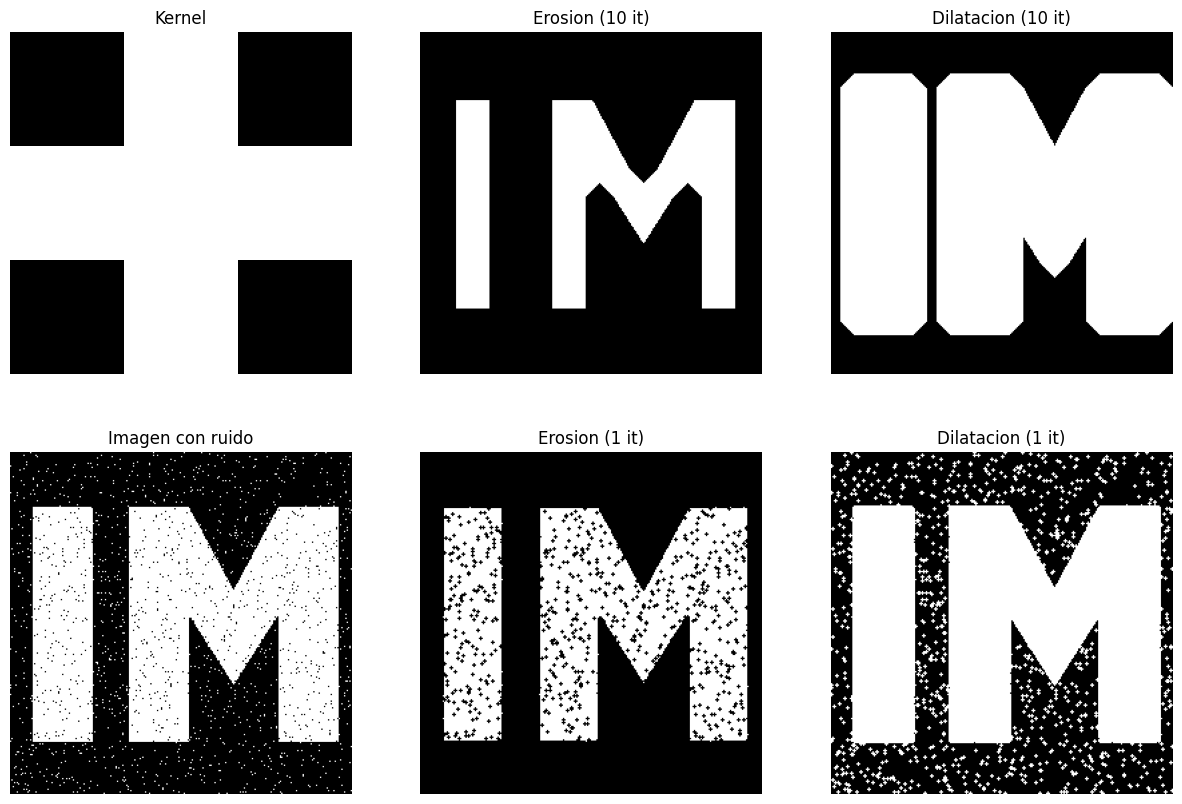

In [362]:
letras = cv2.imread('imagenes/letras1.tif', cv2.IMREAD_GRAYSCALE)

kernel = 255*np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0],
], dtype=np.uint8)

_, letras_bin = cv2.threshold(letras, 128, 255, cv2.THRESH_BINARY)
letras_bin_ruido = aplicar_ruido_salpi(letras_bin, 0.05)

letras_erosion = cv2.erode(letras_bin, kernel, iterations=10)
letras_dilatacion = cv2.dilate(letras_bin, kernel, iterations=10)
letras_erosion_ruido = cv2.erode(letras_bin_ruido, kernel, iterations=1)
letras_dilatacion_ruido = cv2.dilate(letras_bin_ruido, kernel, iterations=1)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0,0].imshow(kernel, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title(f"Kernel"); ax[0,0].axis('off')
ax[0,1].imshow(letras_erosion, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title(f"Erosion (10 it)"); ax[0,1].axis('off')
ax[0,2].imshow(letras_dilatacion, cmap='gray', vmin=0, vmax=255); ax[0,2].set_title(f"Dilatacion (10 it)"); ax[0,2].axis('off');
ax[1,0].imshow(letras_bin_ruido, cmap='gray', vmin=0, vmax=255); ax[1,0].set_title(f"Imagen con ruido"); ax[1,0].axis('off')
ax[1,1].imshow(letras_erosion_ruido, cmap='gray', vmin=0, vmax=255); ax[1,1].set_title(f"Erosion (1 it)"); ax[1,1].axis('off')
ax[1,2].imshow(letras_dilatacion_ruido, cmap='gray', vmin=0, vmax=255); ax[1,2].set_title(f"Dilatacion (1 it)"); ax[1,2].axis('off');

Más alla de lo obvio, que es que al dilatar amplificamos el ruido de pimienta y al erosionar amplificamos el ruido de sal, también es valioso ver que a la vez que se amplifica uno, se filtra el otro: en la erosión filtramos el ruido de sal y en la dilatación filtramos el ruido de pimienta

## Ejercicio 1.2

Utilizando la imagen `fosforos.jpg`, extraiga en una imagen los fósforos que están vertifcales y en otra los orizontales.

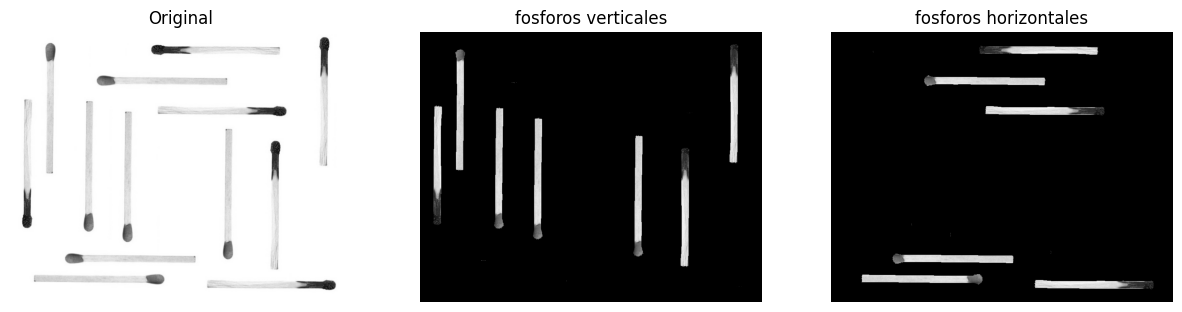

In [363]:
fosforos = cv2.imread('imagenes/fosforos.jpg', cv2.IMREAD_GRAYSCALE)

_, fosforos_bin = cv2.threshold(fosforos, 250, 255, cv2.THRESH_BINARY_INV)

kv = 255*np.array(
    [
        [1],
        [1],
        [1],
        [1],
    ], dtype=np.uint8
)
kh = 255*np.array(
    [
        [1,1,1,1],
    ], dtype=np.uint8
)

mascara_fosforos_v = cv2.erode(fosforos_bin, kv, iterations=10)
mascara_fosforos_h = cv2.erode(fosforos_bin, kh, iterations=10)
fosforos_v = cv2.bitwise_and(fosforos, mascara_fosforos_v)
fosforos_h = cv2.bitwise_and(fosforos, mascara_fosforos_h)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(fosforos, cmap='gray', vmin=0, vmax=255); ax[0].set_title(f"Original"); ax[0].axis('off')
ax[1].imshow(fosforos_v, cmap='gray', vmin=0, vmax=255); ax[1].set_title(f"fosforos verticales"); ax[1].axis('off')
ax[2].imshow(fosforos_h, cmap='gray', vmin=0, vmax=255); ax[2].set_title(f"fosforos horizontales"); ax[2].axis('off');

# Ejercicio 1.3

Implemente una secuencia de operaciones (incluyendo operaciones aritméticas y lógicas), con diferentes EE, que le permitan extraer el logo de la imagen `createch01.png`. En principio, ignore las letras pero (opcionalmente) si se le ocurre como quitarlas de forma automática, hágalo.
_Pista_: extraer el logo por partes y combinarlas n una imagen final.

> Voy a aplicar cierre con EE cuadrados de distintos tamaños para extraer los idem.

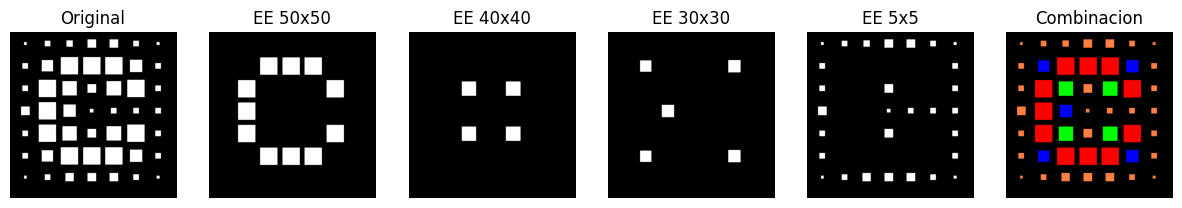

In [364]:
createch = cv2.imread('imagenes/createch01.png', cv2.IMREAD_GRAYSCALE)
logo = createch[0:500,250:750]

_, logo_bin = cv2.threshold(logo, 125, 255, cv2.THRESH_BINARY_INV)
k1 = np.ones((50,50)).astype(np.uint8)  # con kernel grande extraemos los cuadrados grandes
logo1 = cv2.erode(logo_bin,k1)             # erosión elimina los chiquitos
logo1 = cv2.dilate(logo1,k1)                  # "restaura" los sobrevivientes a tamaño normal

mask = cv2.bitwise_not(logo1)
img2 = cv2.bitwise_and(logo_bin,logo_bin,mask=mask)

k2 = np.ones((40,40)).astype(np.uint8)
logo2 = cv2.erode(img2,k2)
logo2 = cv2.dilate(logo2,k2)

mask = cv2.bitwise_not(logo2)
img3 = cv2.bitwise_and(img2,img2,mask=mask)

k3 = np.ones((30,30)).astype(np.uint8)
logo3 = cv2.erode(img3,k3)
logo3 = cv2.dilate(logo3,k3)

mask = cv2.bitwise_not(logo3)
img4 = cv2.bitwise_and(img3,img3,mask=mask)

k4 = np.ones((5,5)).astype(np.uint8)
logo4 = cv2.erode(img4,k4)
logo4 = cv2.dilate(logo4,k4)

# final
img = np.zeros((logo.shape[0], logo.shape[1], 3), dtype=np.uint8)
img[logo1 == 255] = [255,0,0]
img[logo2 == 255] = [0,255,0]
img[logo3 == 255] = [0,0,255]
img[logo4 == 255] = [255,128,64]

fig, ax = plt.subplots(1, 6, figsize=(15, 5))

ax[0].imshow(logo_bin, cmap='gray', vmin=0, vmax=255); ax[0].set_title(f"Original"); ax[0].axis('off');
ax[1].imshow(logo1, cmap='gray', vmin=0, vmax=255); ax[1].set_title(f"EE 50x50"); ax[1].axis('off')
ax[2].imshow(logo2, cmap='gray', vmin=0, vmax=255); ax[2].set_title(f"EE 40x40"); ax[2].axis('off');
ax[3].imshow(logo3, cmap='gray', vmin=0, vmax=255); ax[3].set_title(f"EE 30x30"); ax[3].axis('off');
ax[4].imshow(logo4, cmap='gray', vmin=0, vmax=255); ax[4].set_title(f"EE 5x5"); ax[4].axis('off');
ax[5].imshow(img); ax[5].set_title(f"Combinacion"); ax[5].axis('off');

# Ejercicio 2

Operaciones de apertura y cierre

## Ejercicio 2.1

Realice las operaicones de apertura y cierre sobre la imagen  (debe generarla) utilizando el EE que se muestra a continuación.

- Utilice otros EE, pueden ser los que definió antes, y vuelva a realizar las operaciones. Comente los resultado.
- ¿Estas operaciones le parecen útiles para los ejercicios 1.2 y 1.3? ¿Se anima a utilizarlos y probar su funcionamiento?

In [365]:
def aplicar_apertura(img, kernel):
    img_apertura = cv2.erode(img,kernel)
    img_apertura = cv2.dilate(img_apertura,kernel)
    return img_apertura

def aplicar_cierre(img, kernel):
    img_cierre = cv2.dilate(img,kernel)
    img_cierre = cv2.erode(img_cierre,kernel)
    return img_cierre

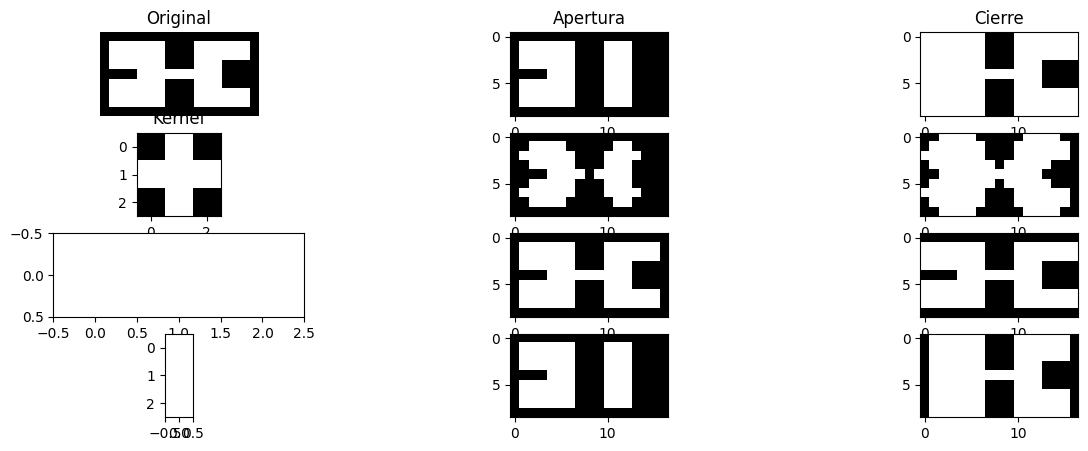

In [366]:
imgEj4 = 255*np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,0,0,0,1,1,1,0,0,0,0],
    [0,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0,0],
    [0,1,1,1,1,1,1,0,0,0,1,1,1,0,0,0,0],
    [0,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,0],
    [0,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
], dtype=np.uint8)

kernel1 = 255*np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1],
], dtype=np.uint8)

kernel2 = 255*np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0],
], dtype=np.uint8)

kernel3 = 255*np.array([
    [1,1,1],
], dtype=np.uint8)

kernel4 = 255*np.array([
    [1],
    [1],
    [1],
], dtype=np.uint8)

imgEj4_apertura1 = aplicar_apertura(imgEj4, kernel1)
imgEj4_cierre1 = aplicar_cierre(imgEj4, kernel1)
imgEj4_apertura2 = aplicar_apertura(imgEj4, kernel2)
imgEj4_cierre2 = aplicar_cierre(imgEj4, kernel2)
imgEj4_apertura3 = aplicar_apertura(imgEj4, kernel3)
imgEj4_cierre3 = aplicar_cierre(imgEj4, kernel3)
imgEj4_apertura4 = aplicar_apertura(imgEj4, kernel4)
imgEj4_cierre4 = aplicar_cierre(imgEj4, kernel4)

fig, ax = plt.subplots(4, 3, figsize=(15, 5))

ax[0,0].imshow(imgEj4, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title(f"Original"); ax[0,0].axis('off');
ax[0,1].imshow(imgEj4_apertura1, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title(f"Apertura");
ax[0,2].imshow(imgEj4_cierre1, cmap='gray', vmin=0, vmax=255); ax[0,2].set_title(f"Cierre");
ax[1,0].imshow(kernel2, cmap='gray', vmin=0, vmax=255); ax[1,0].set_title(f"Kernel");
ax[1,1].imshow(imgEj4_apertura2, cmap='gray', vmin=0, vmax=255);
ax[1,2].imshow(imgEj4_cierre2, cmap='gray', vmin=0, vmax=255);
ax[2,0].imshow(kernel3, cmap='gray', vmin=0, vmax=255);
ax[2,1].imshow(imgEj4_apertura3, cmap='gray', vmin=0, vmax=255);
ax[2,2].imshow(imgEj4_cierre3, cmap='gray', vmin=0, vmax=255);
ax[3,0].imshow(kernel4, cmap='gray', vmin=0, vmax=255);
ax[3,1].imshow(imgEj4_apertura4, cmap='gray', vmin=0, vmax=255);
ax[3,2].imshow(imgEj4_cierre4, cmap='gray', vmin=0, vmax=255);

## Ejercicio 2.2

Extraiga de la imagen `estrella.jpg` sólo las estrellas que se observan de mayor tamaño.

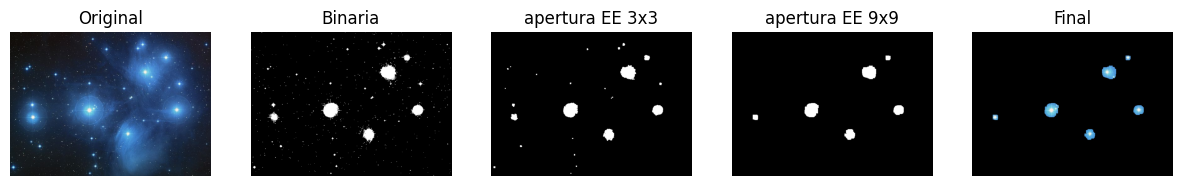

In [367]:
estrellas = cv2.imread('imagenes/estrellas.jpg', cv2.IMREAD_COLOR_RGB)
_, estrellas_bin = cv2.threshold(cv2.cvtColor(estrellas, cv2.COLOR_RGB2GRAY), 130, 255, cv2.THRESH_BINARY)

EEchico = np.ones((3,3)).astype(np.uint8)
EEgrande = np.ones((9,9)).astype(np.uint8)

mascara_estrellas_medianas = aplicar_apertura(estrellas_bin, EEchico)
mascara_estrellas_grandes = aplicar_apertura(mascara_estrellas_medianas, EEgrande)

estrellas_grandes = cv2.bitwise_and(estrellas, estrellas, mask=mascara_estrellas_grandes)

fig, ax = plt.subplots(1, 5, figsize=(15, 5))

ax[0].imshow(estrellas, vmin=0, vmax=255); ax[0].set_title(f"Original"); ax[0].axis('off');
ax[1].imshow(estrellas_bin, cmap='gray', vmin=0, vmax=255); ax[1].set_title(f"Binaria"); ax[1].axis('off')
ax[2].imshow(mascara_estrellas_medianas, cmap='gray', vmin=0, vmax=255); ax[2].set_title(f"apertura EE 3x3"); ax[2].axis('off');
ax[3].imshow(mascara_estrellas_grandes, cmap='gray', vmin=0, vmax=255); ax[3].set_title(f"apertura EE 9x9"); ax[3].axis('off');
ax[4].imshow(estrellas_grandes, vmin=0, vmax=255); ax[4].set_title(f"Final"); ax[4].axis('off');

## Ejercicio 2.3

Diseñe un EE que le permita extraer la estrella fugaz de la imagen `lluviaEstrellas.jpg`

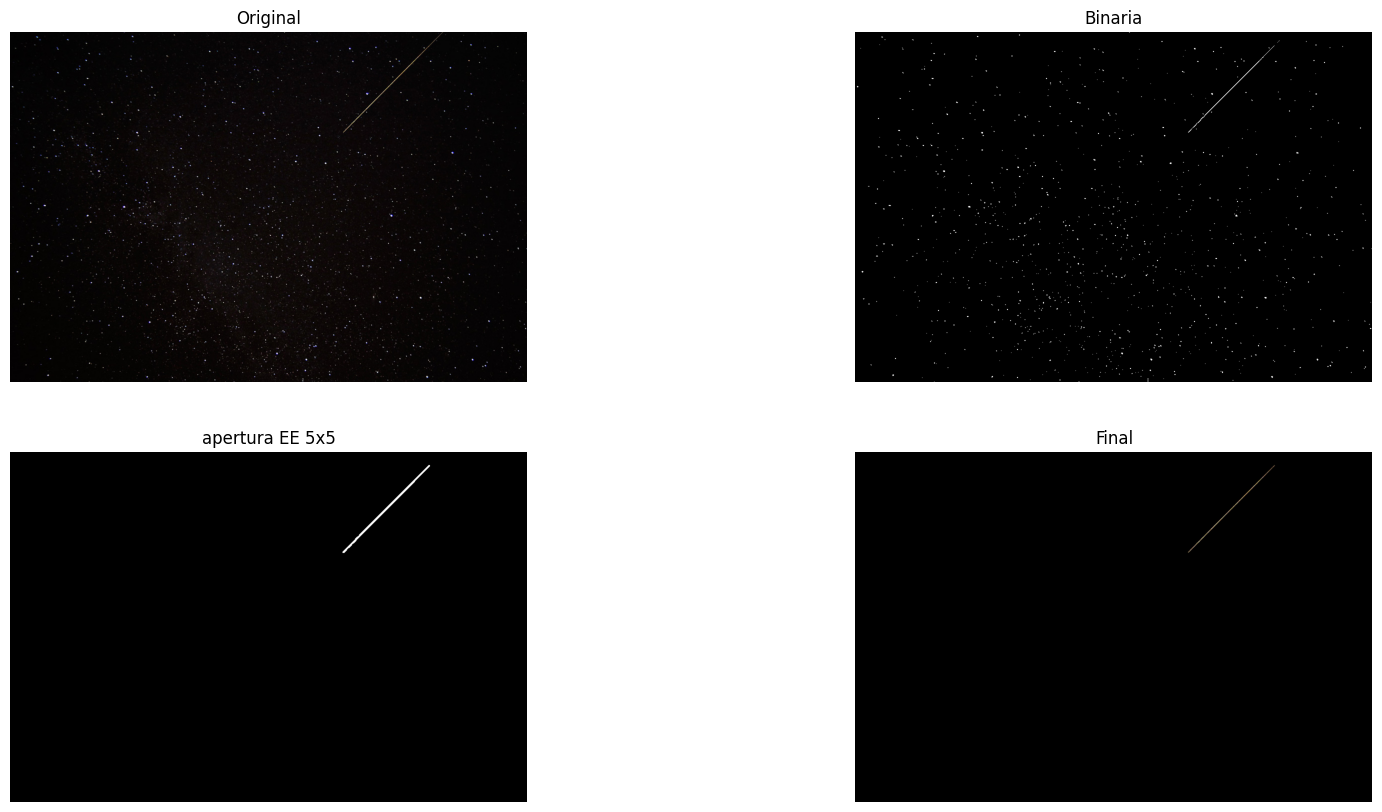

In [368]:
lluvia = cv2.imread('imagenes/lluviaEstrellas.jpg', cv2.IMREAD_COLOR_RGB)
_, lluvia_bin = cv2.threshold(cv2.cvtColor(lluvia, cv2.COLOR_RGB2GRAY), 90, 255, cv2.THRESH_BINARY)

EE = 255*np.array([
    [0,0,0,0,1],
    [0,0,0,1,0],
    [0,0,1,0,0],
    [0,1,0,0,0],
    [1,0,0,0,0],
], dtype=np.uint8)

# apertura
mascara_estrella_fugaz = cv2.morphologyEx(lluvia_bin, cv2.MORPH_OPEN, EE)

# dilatacion para tomar un poco mas de area
mascara_estrella_fugaz = cv2.dilate(mascara_estrella_fugaz, np.ones((3,3)).astype(np.uint8))

estrella_fugaz = cv2.bitwise_and(lluvia, lluvia, mask=mascara_estrella_fugaz)

fig, ax = plt.subplots(2, 2, figsize=(20, 10))

ax[0,0].imshow(lluvia, vmin=0, vmax=255); ax[0,0].set_title(f"Original"); ax[0,0].axis('off');
ax[0,1].imshow(lluvia_bin, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title(f"Binaria"); ax[0,1].axis('off');
ax[1,0].imshow(mascara_estrella_fugaz, cmap='gray', vmin=0, vmax=255); ax[1,0].set_title(f"apertura EE 5x5"); ax[1,0].axis('off');
ax[1,1].imshow(estrella_fugaz, cmap='gray', vmin=0, vmax=255); ax[1,1].set_title(f"Final"); ax[1,1].axis('off');

# Ejercicio 3

Gradiente morfológico

- Utilice el gradiente morfológico para obtener los bordes de las imágenes `fosforos.jpg` y `createch01.jpg`.

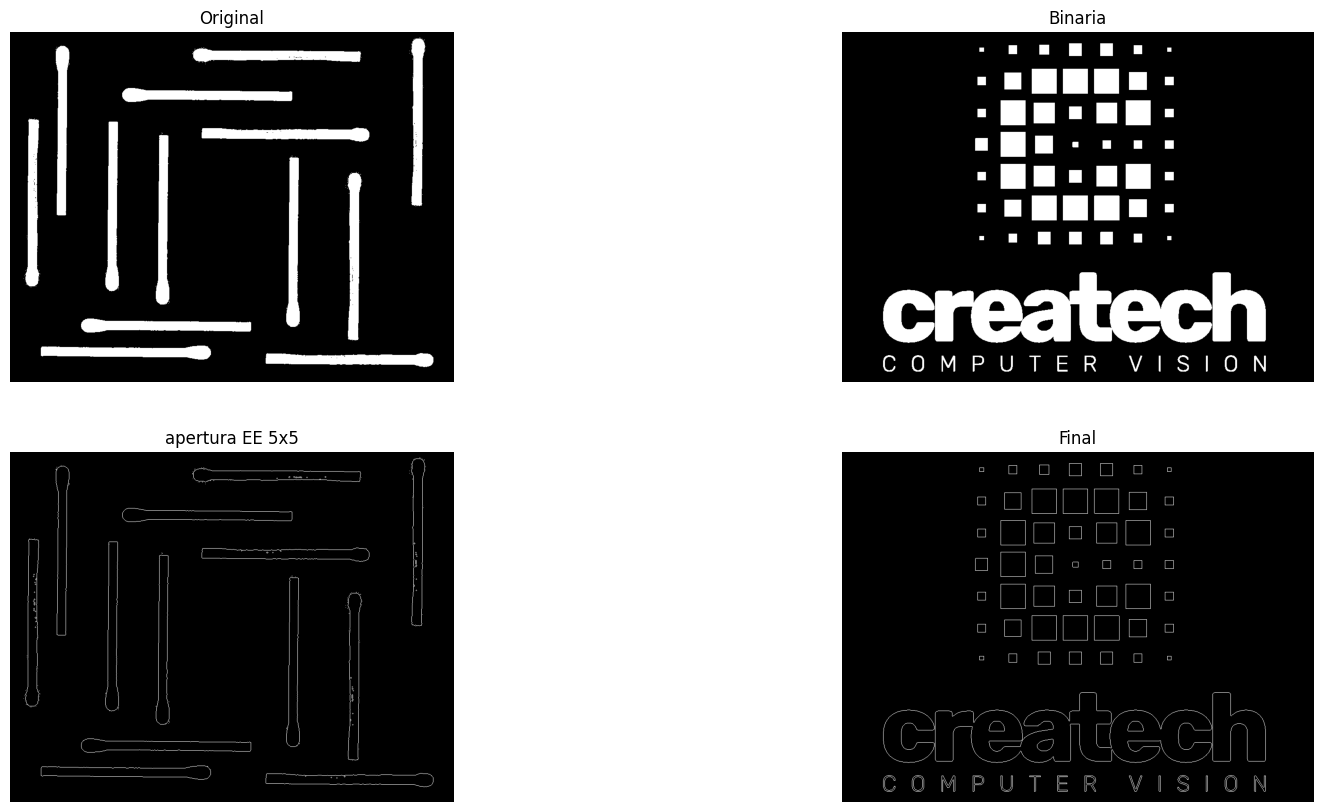

In [369]:
fosforos = cv2.imread('imagenes/fosforos.jpg', cv2.IMREAD_GRAYSCALE)
createch = cv2.imread('imagenes/createch01.png', cv2.IMREAD_GRAYSCALE)

_,fosforos_bin = cv2.threshold(fosforos,245,255,cv2.THRESH_BINARY_INV)
_,createch_bin = cv2.threshold(createch,245,255,cv2.THRESH_BINARY_INV)

EE = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
bordes_fosforos = fosforos_bin - cv2.erode(fosforos_bin, EE)
bordes_createch = createch_bin - cv2.erode(createch_bin, EE)

fig, ax = plt.subplots(2, 2, figsize=(20, 10))

ax[0,0].imshow(fosforos_bin, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title(f"Original"); ax[0,0].axis('off');
ax[0,1].imshow(createch_bin, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title(f"Binaria"); ax[0,1].axis('off');
ax[1,0].imshow(bordes_fosforos, cmap='gray', vmin=0, vmax=255); ax[1,0].set_title(f"apertura EE 5x5"); ax[1,0].axis('off');
ax[1,1].imshow(bordes_createch, cmap='gray', vmin=0, vmax=255); ax[1,1].set_title(f"Final"); ax[1,1].axis('off');

Compare los resultados con la aplicación de los detectores de Sobel y Canny

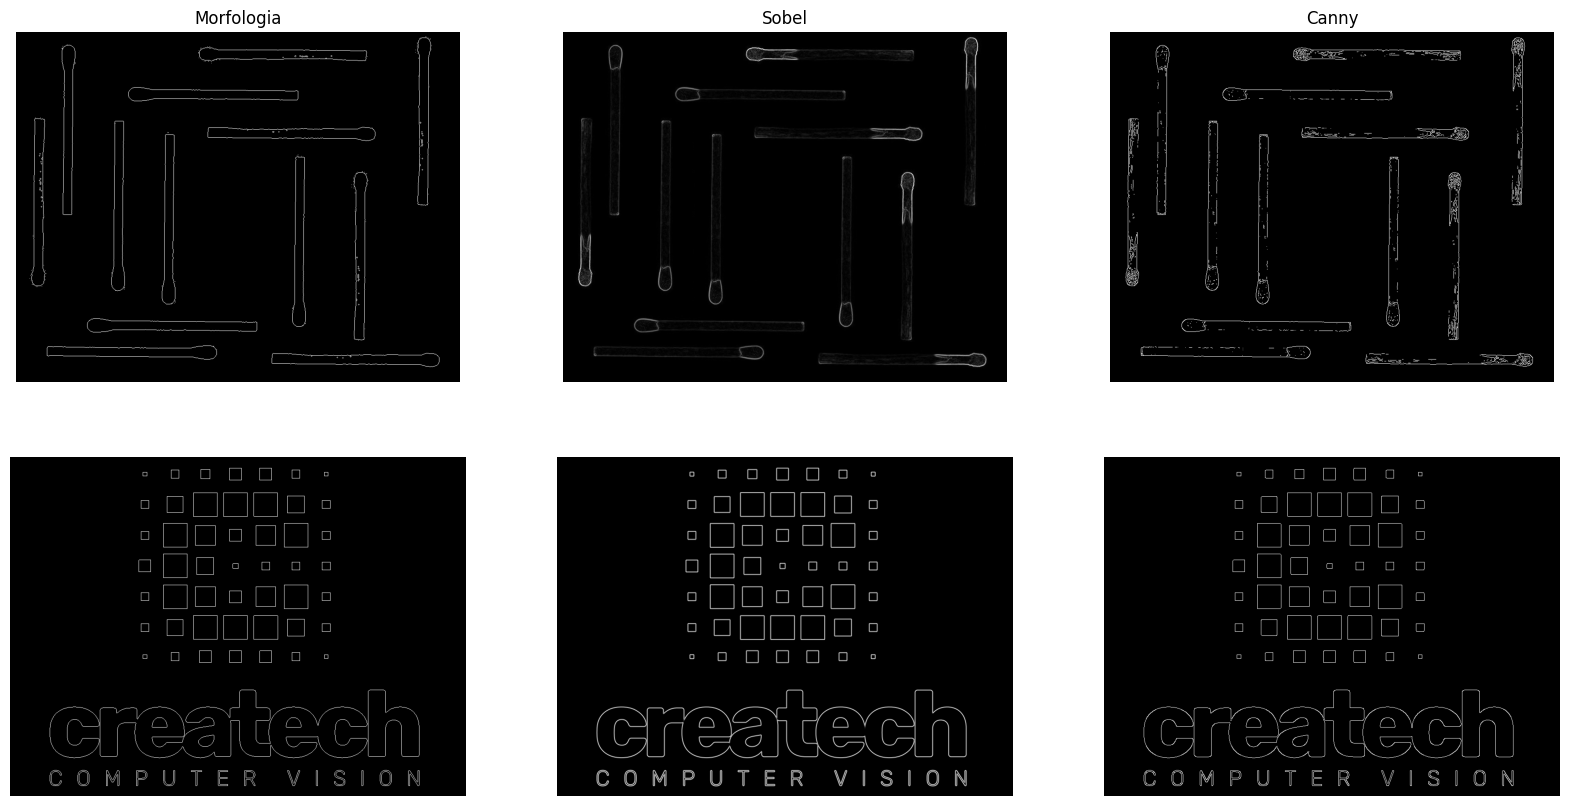

In [370]:
def aplicar_sobel(img, ksize, dx=0, dy=0, bidireccional=True, ddepth=cv2.CV_64F):
    if bidireccional:
        sobelx = cv2.Sobel(img, ddepth, dx=1, dy=0, ksize=ksize)
        sobely = cv2.Sobel(img, ddepth, dx=0, dy=1, ksize=ksize)

        return cv2.magnitude(sobelx.astype(np.float64), sobely.astype(np.float64))
    else:
        return cv2.Sobel(img, ddepth, dx=dx, dy=dy, ksize=ksize)

fosforos_sobel = aplicar_sobel(fosforos, 1)
createch_sobel = aplicar_sobel(createch, 1)

fosforos_canny = cv2.Canny(fosforos, 100, 100, L2gradient=False)
createch_canny = cv2.Canny(createch, 100, 100, L2gradient=False)

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

ax[0,0].imshow(bordes_fosforos, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title(f"Morfologia"); ax[0,0].axis('off');
ax[0,1].imshow(fosforos_sobel, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title(f"Sobel"); ax[0,1].axis('off');
ax[0,2].imshow(fosforos_canny, cmap='gray', vmin=0, vmax=255); ax[0,2].set_title(f"Canny"); ax[0,2].axis('off');
ax[1,0].imshow(bordes_createch, cmap='gray', vmin=0, vmax=255); ax[1,0].axis('off');
ax[1,1].imshow(createch_sobel, cmap='gray', vmin=0, vmax=255); ax[1,1].axis('off');
ax[1,2].imshow(createch_canny, cmap='gray', vmin=0, vmax=255); ax[1,2].axis('off');

Agregue ruido sal y pimienta a las imágenes, vuelva a aplicar los 3 métodos y compare resultados.

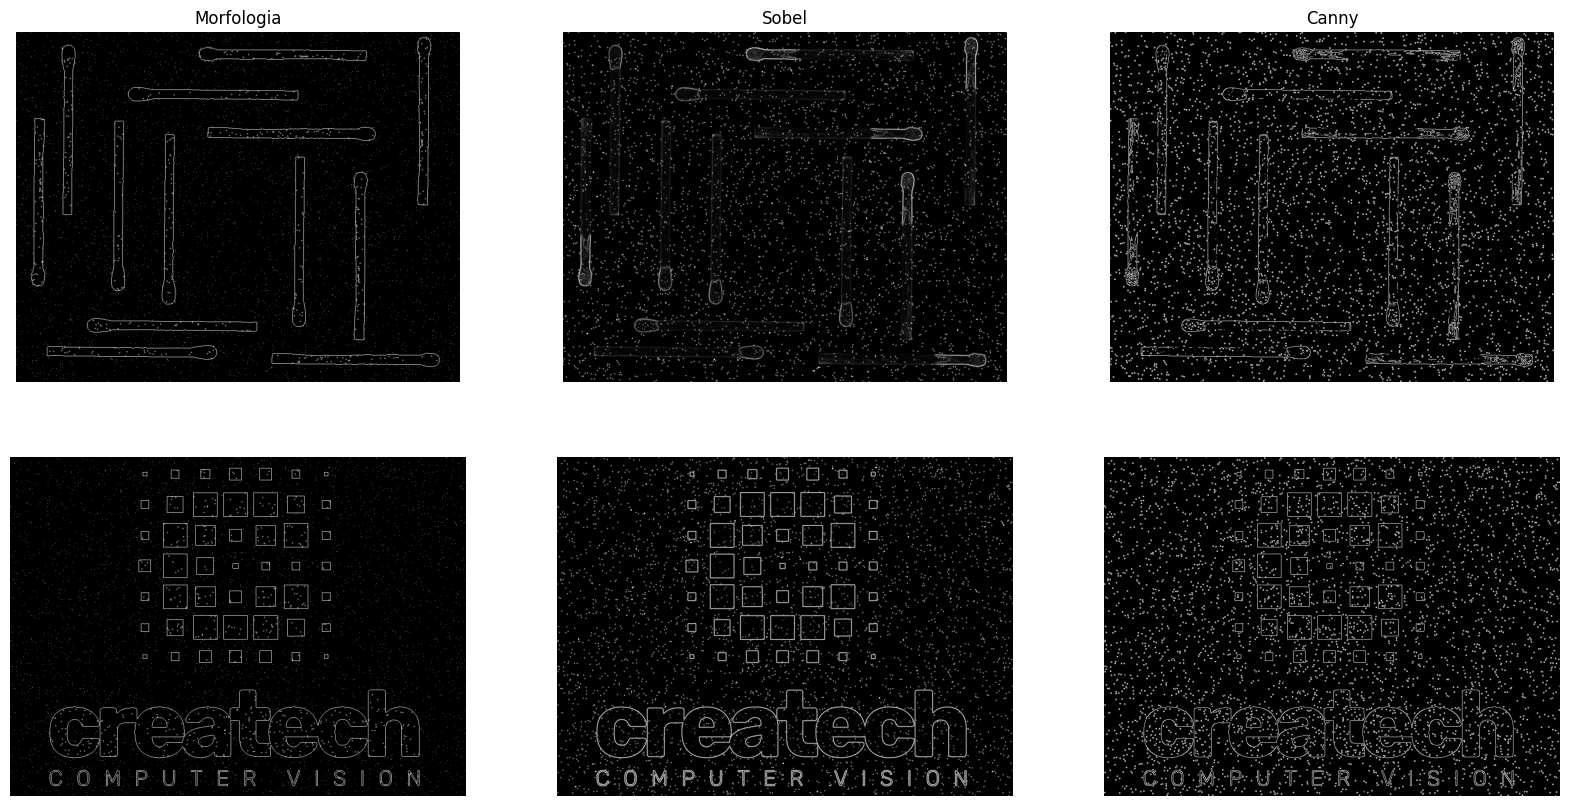

In [371]:
fosforos = aplicar_ruido_salpi(fosforos, 0.01)
createch = aplicar_ruido_salpi(createch, 0.01)

_,fosforos_bin = cv2.threshold(fosforos,245,255,cv2.THRESH_BINARY_INV)
_,createch_bin = cv2.threshold(createch,245,255,cv2.THRESH_BINARY_INV)

EE = cv2.getStructuringElement(cv2.MORPH_CROSS,(3,3))
bordes_fosforos = fosforos_bin - cv2.erode(fosforos_bin, EE)
bordes_createch = createch_bin - cv2.erode(createch_bin, EE)

fosforos_sobel = aplicar_sobel(fosforos, 1)
createch_sobel = aplicar_sobel(createch, 1)

fosforos_canny = cv2.Canny(fosforos, 100, 100, L2gradient=False)
createch_canny = cv2.Canny(createch, 100, 100, L2gradient=False)

fig, ax = plt.subplots(2, 3, figsize=(20, 10))

ax[0,0].imshow(bordes_fosforos, cmap='gray', vmin=0, vmax=255); ax[0,0].set_title(f"Morfologia"); ax[0,0].axis('off');
ax[0,1].imshow(fosforos_sobel, cmap='gray', vmin=0, vmax=255); ax[0,1].set_title(f"Sobel"); ax[0,1].axis('off');
ax[0,2].imshow(fosforos_canny, cmap='gray', vmin=0, vmax=255); ax[0,2].set_title(f"Canny"); ax[0,2].axis('off');
ax[1,0].imshow(bordes_createch, cmap='gray', vmin=0, vmax=255); ax[1,0].axis('off');
ax[1,1].imshow(createch_sobel, cmap='gray', vmin=0, vmax=255); ax[1,1].axis('off');
ax[1,2].imshow(createch_canny, cmap='gray', vmin=0, vmax=255); ax[1,2].axis('off');

> Vemos que el gradiente morfológico sirve tanto para imágenes artificiales (logo) como para reales (fosforos), con lineas continuas y sin agregar artefactos con en Sobel o Canny. Además, es el que menos amplifica el ruido impulsivo. En general los resultados mejorarian haciendo un filtrado del ruido S&P antes.

# Ejercicio 4

Considere la imagen `Caracteres.jpeg`, puede escalarla para simplificar el procesamiento.

## Ejercicio 4.1

Aplique Hit-or-Miss para encontrar las letras I, E y T

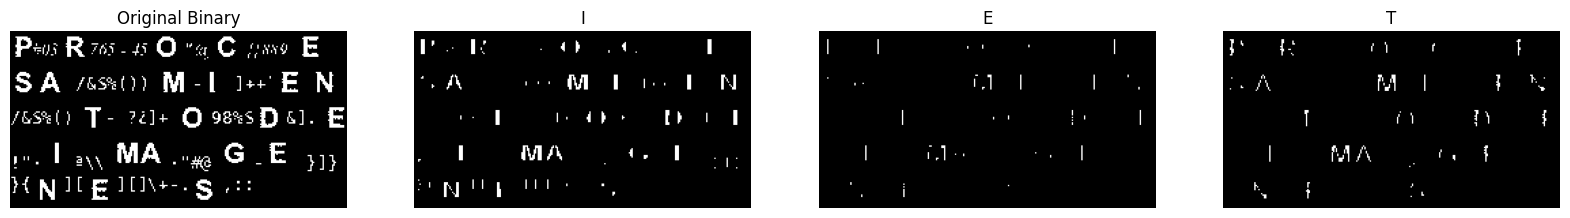

In [372]:
caracteres = cv2.imread('imagenes/Caracteres.jpeg', cv2.IMREAD_GRAYSCALE)
_, caracteres_bin = cv2.threshold(caracteres, 128, 255, cv2.THRESH_BINARY_INV)

# kernels
kernel_I = np.array([
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0],
], dtype=np.int8)

kernel_E = np.array([
    [1, 1, 1],
    [1, 0, 0],
    [1, 1, 1],
    [1, 0, 0],
    [1, 1, 1],
], dtype=np.int8)

kernel_T = np.array([
    [1, 1, 1],
    [0, 1, 0],
    [0, 1, 0],
    [0, 1, 0],
], dtype=np.int8)

# aplicar hit or miss
result_I = cv2.morphologyEx(caracteres_bin, cv2.MORPH_HITMISS, kernel_I)
result_E = cv2.morphologyEx(caracteres_bin, cv2.MORPH_HITMISS, kernel_E)
result_T = cv2.morphologyEx(caracteres_bin, cv2.MORPH_HITMISS, kernel_T)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(caracteres_bin, cmap='gray', vmin=0, vmax=255); ax[0].set_title("Original Binary"); ax[0].axis('off')
ax[1].imshow(result_I, cmap='gray', vmin=0, vmax=255); ax[1].set_title("I"); ax[1].axis('off')
ax[2].imshow(result_E, cmap='gray', vmin=0, vmax=255); ax[2].set_title("E"); ax[2].axis('off')
ax[3].imshow(result_T, cmap='gray', vmin=0, vmax=255); ax[3].set_title("T"); ax[3].axis('off');

> Para la letra I se recupera un resultado relativamente aceptable con kernels hechos a mano. Se recuperan las I's y partes parecidas de otras letras (como los palos de la M o la O).
>
> En el caso de la E y la T, no se encontraron kernels que arrojen resultados ni remotamente aceptables. Se intento con kernels pequeños y con kernels con el tamaño exacto de las letras

# Ejercicio 5

Trabajos de aplicación

## Ejercicio 5.1

Obtenga el nombre completo, profesión y las siglas de la empresa a la que pertenece la tarjeta personal de la imagen

_Obtenga el tresto de la información en otra imagen_

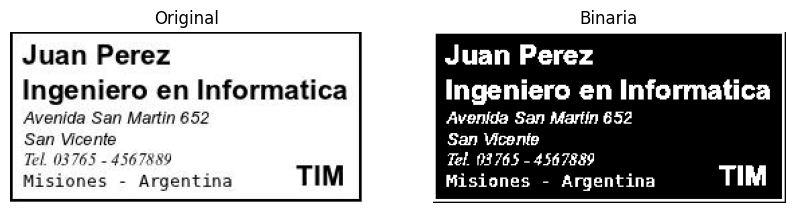

In [373]:
tarjeta = cv2.imread("imagenes/Tarjeta.jpeg",cv2.IMREAD_GRAYSCALE)
_,tarjeta_binario = cv2.threshold(tarjeta,200,255,cv2.THRESH_BINARY_INV)

fig, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(tarjeta,cmap="gray"); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(tarjeta_binario,cmap="gray"); ax[1].set_title("Binaria"); ax[1].axis('off')
plt.show();

apertura para obtenes letras grandes y otra apertura para eliminar ruido remanente

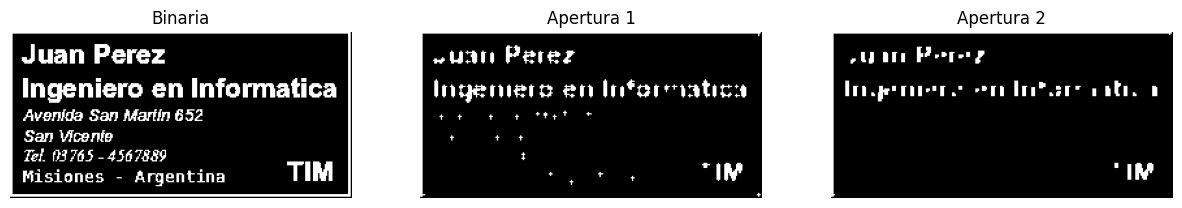

In [374]:
EEletras = cv2.getStructuringElement(cv2.MORPH_CROSS, (4,4))
EEruido = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

# apertura
mascara_tarjeta_apertura1 = cv2.morphologyEx(tarjeta_binario, cv2.MORPH_OPEN, EEletras)
# aplicar mascara
tarjeta_apertura1 = cv2.bitwise_and(tarjeta_binario,tarjeta_binario,mask=mascara_tarjeta_apertura1)
# apertura
mascara_tarjeta_apertura2 = cv2.morphologyEx(mascara_tarjeta_apertura1, cv2.MORPH_OPEN, EEruido)
# aplicar mascara
tarjeta_apertura2 = cv2.bitwise_and(tarjeta_binario,tarjeta_binario,mask=mascara_tarjeta_apertura2)

fig, ax = plt.subplots(1, 3, figsize=(15,10))
ax[0].imshow(tarjeta_binario,cmap="gray"); ax[0].set_title("Binaria"); ax[0].axis('off')
ax[1].imshow(tarjeta_apertura1,cmap="gray"); ax[1].set_title("Apertura 1"); ax[1].axis('off')
ax[2].imshow(tarjeta_apertura2,cmap="gray"); ax[2].set_title("Apertura 2"); ax[2].axis('off')
plt.show();

Reconstruimos un poco las letras con dilatiacion

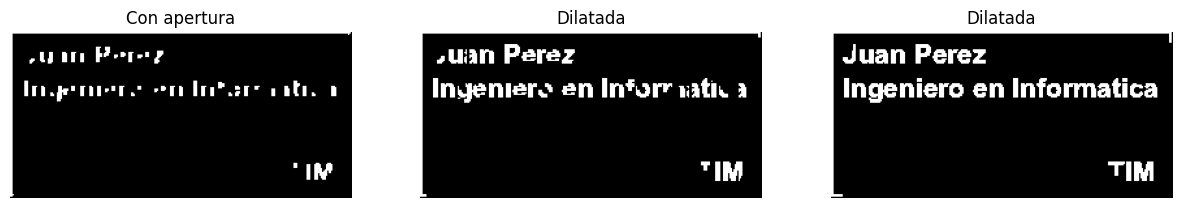

In [375]:
# dilatar la mascara, no la tarjeta con la mascara aplicada
EEdilat = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
mascara_dilatacion1 = cv2.morphologyEx(mascara_tarjeta_apertura2, cv2.MORPH_DILATE, EEdilat)

# aplicar mascara
tarjeta_dilatada1 = cv2.bitwise_and(tarjeta_binario, tarjeta_binario, mask=mascara_dilatacion1)

# repetir la dilatacion
EEdilat = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))
mascara_dilatacion2 = cv2.morphologyEx(mascara_dilatacion1, cv2.MORPH_DILATE, EEdilat)
tarjeta_nombre = cv2.bitwise_and(tarjeta_binario, tarjeta_binario, mask=mascara_dilatacion2)

fig, ax = plt.subplots(1, 3, figsize=(15,10))
ax[0].imshow(tarjeta_apertura2,cmap="gray"); ax[0].set_title("Con apertura"); ax[0].axis('off')
ax[1].imshow(tarjeta_dilatada1,cmap="gray"); ax[1].set_title("Dilatada"); ax[1].axis('off')
ax[2].imshow(tarjeta_nombre,cmap="gray"); ax[2].set_title("Dilatada"); ax[2].axis('off')
plt.show();

Obtenemos los otros datos invirtiendo la máscara

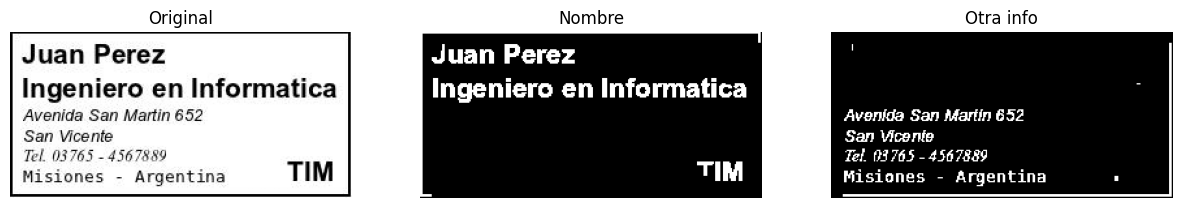

In [376]:
tarjeta_info = cv2.bitwise_and(tarjeta_binario, tarjeta_binario, mask=255-mascara_dilatacion2)

fig, ax = plt.subplots(1, 3, figsize=(15,10))
ax[0].imshow(tarjeta,cmap="gray"); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(tarjeta_nombre,cmap="gray"); ax[1].set_title("Nombre"); ax[1].axis('off')
ax[2].imshow(tarjeta_info,cmap="gray"); ax[2].set_title("Otra info"); ax[2].axis('off')
plt.show();

El resultado es aceptable. Los errores que pueden apreciarse son por ejemplo la T en el nombre de la empresa o algunos pedazos de la "J" de "Juan" o la "c" de "Informatica".

## Ejercicio 5.2

Entre las múltiples facetas del "viejo del a teoría", se destaca la de músico prolífico y, como usted sabrá, le gusta mucho la tecnología.

Podrá usted congraciarse con él y proveerle un programa que le permita extraer las notas musicales del pentagrama (`notas01.png`). El tema es _Embrujo de mi tierra_ de Peteco Carabajal.

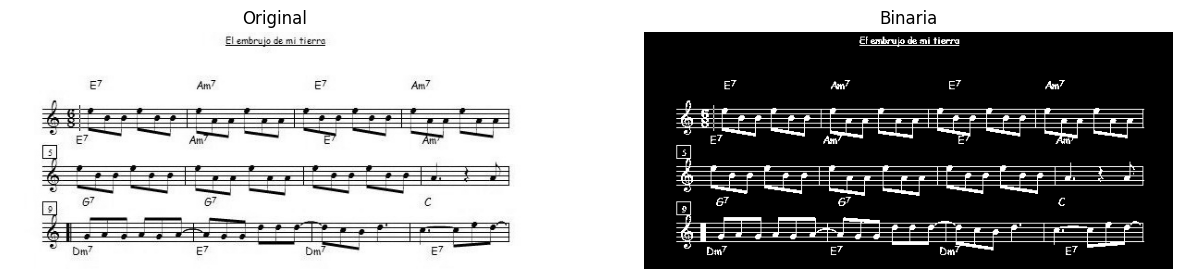

In [377]:
pentagrama = cv2.imread("imagenes/notas01.png",cv2.IMREAD_GRAYSCALE)
_, pentagrama_bin = cv2.threshold(pentagrama,200,255,cv2.THRESH_BINARY_INV)

fig, ax = plt.subplots(1, 2, figsize=(15,10))
ax[0].imshow(pentagrama, cmap="gray"); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(pentagrama_bin,cmap="gray"); ax[1].set_title("Binaria"); ax[1].axis('off')
plt.show();

Segmentamos por connectedComponents (las que mayor area tendran, salvo por el fondo)

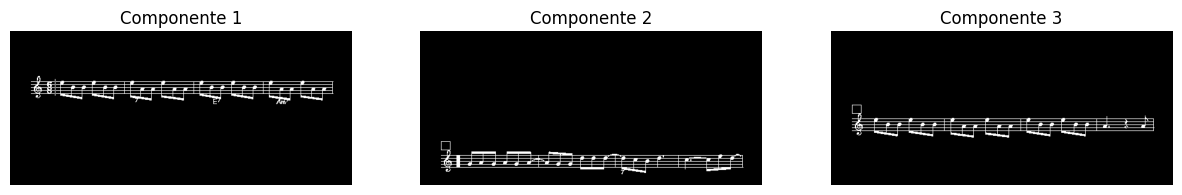

In [378]:
# segmentacion por connectedComponents
num_labels, labels = cv2.connectedComponents(pentagrama_bin)

# labels y areas
unique_labels, label_counts = np.unique(labels, return_counts=True)
areas = [(label, count) for label, count in zip(unique_labels, label_counts)]

# ordenar por area
areas.sort(key=lambda x: x[1], reverse=True)

# obtener tres componentes mas grandes en area (exceptuando el fondo)
componentes = areas[1:4]
mascaras = []

# mascaras
for label, _ in componentes:
    mask = np.uint8(labels == label)
    mascaras.append(mask)

fig, ax = plt.subplots(1, 3, figsize=(15,10))
ax[0].imshow(pentagrama,cmap="gray"); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(pentagrama_bin,cmap="gray"); ax[1].set_title("Binaria"); ax[1].axis('off')
for i, mask in enumerate(mascaras):
    ax[i].imshow(mask, cmap='gray')
    ax[i].set_title(f'Componente {i+1}')
    ax[i].axis('off')

plt.show()

Obtenemos las notas quitando los renglones del pentagrama. Se hace una apertura con un kernel horizontal

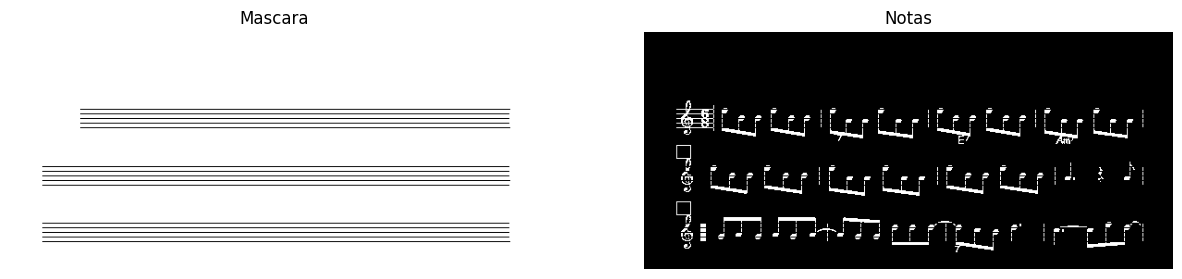

In [379]:
# Obtener una máscara con los tres componentes de mayor área
solo_notas = np.zeros_like(pentagrama_bin, dtype=np.uint8)

for label, _ in componentes:
    mask = np.uint8(labels == label)
    solo_notas += mask

# apertura
mask_notas = cv2.morphologyEx(solo_notas, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (45,1)), iterations=1)

mask_notas = cv2.bitwise_not(mask_notas)
notas = cv2.bitwise_and(solo_notas, mask_notas)

fig,ax = plt.subplots(1,2,figsize=(15,15))
ax[0].imshow(mask_notas,cmap="gray"); ax[0].set_title("Mascara"); ax[0].axis('off')
ax[1].imshow(notas,cmap='gray'); ax[1].set_title("Notas"); ax[1].axis('off')
plt.show()

## Ejercicio 5.3

Se requiere eliminar todos aquellos glóbulos rojos que estén en contacto, directo o indirecto a través de otro, con el borde. Utilice la imagen `Globulos Rojos.jpg`

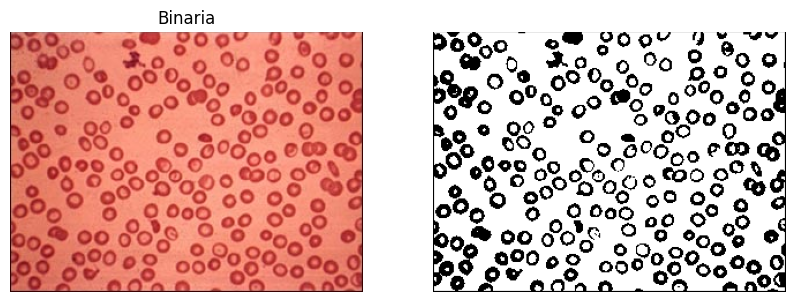

In [380]:
globulos = cv2.imread("imagenes/Globulos Rojos.jpg")
globulos_grises = cv2.cvtColor(globulos, cv2.COLOR_BGR2GRAY)
_,globulos_bin = cv2.threshold(globulos_grises,120,255,cv2.THRESH_BINARY)

fig, ax = plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(globulos[:,:,[2,1,0]],cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(globulos_bin,cmap="gray"); ax[0].set_title("Binaria"); ax[1].axis('off')
plt.show()

Se marca el contorno con los globulos tocando y se substraen de la original

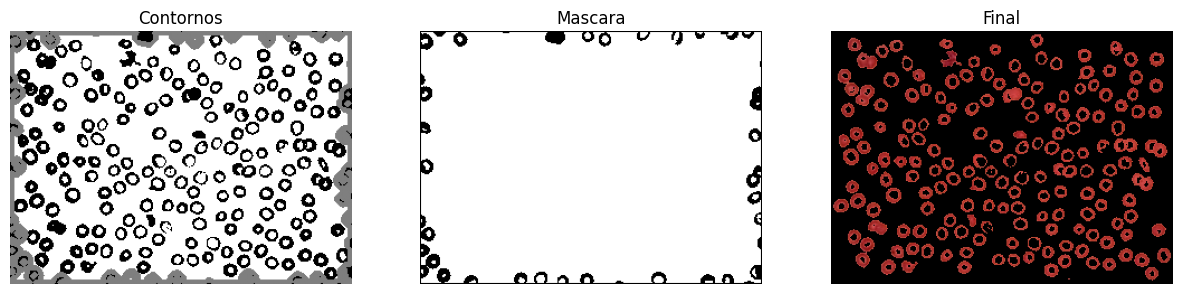

In [381]:
globulos_contornos = globulos_bin.copy()
contours, _ = cv2.findContours(globulos_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask = np.zeros(globulos_bin.shape, np.uint8)
for contour in contours:
  cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)
  cv2.drawContours(globulos_contornos, [contour], -1, 127, thickness=4)

globulos_mask = cv2.subtract(mask,globulos_bin)
globulos_bien = cv2.bitwise_and(globulos,globulos,mask=globulos_mask)

fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(globulos_contornos,cmap='gray'); ax[0].set_title("Contornos"); ax[0].axis('off')
ax[1].imshow(mask,cmap='gray'); ax[1].set_title("Mascara"); ax[1].axis('off')
ax[2].imshow(globulos_bien[:,:,[2,1,0]]); ax[2].set_title("Final"); ax[2].axis('off')
plt.show()

## Ejercicio 5.4

- Genere una máscara binaria con el río de la Plata y sus mayores afluentes
- Utilizando la máscara obtenga la información de la imagen original
- Obtenga el contorno de los ríos

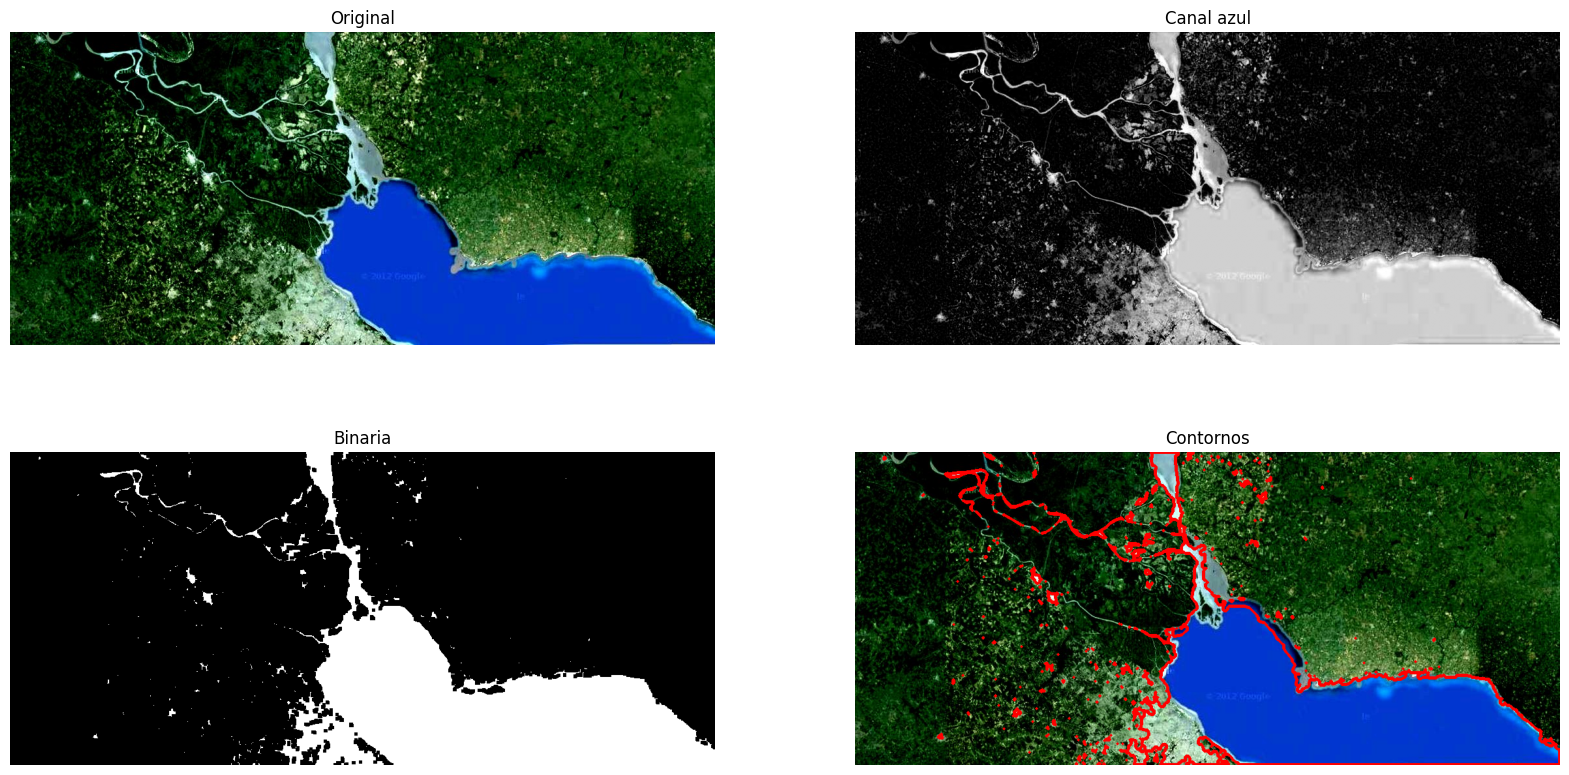

In [382]:
rio = cv2.imread("imagenes/Rio.jpeg", cv2.IMREAD_COLOR_RGB)
rioR, rioG, rioB = cv2.split(rio)

_, rioB_bin = cv2.threshold(rioB, 180, 255, cv2.THRESH_BINARY)

# cierre para mejorar regiones
rioB_bin = cv2.morphologyEx(rioB_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))

# highlight
contornos, _ = cv2.findContours(rioB_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

aux = rio.copy()
cv2.drawContours(aux, contornos, -1, (255, 0, 0), thickness=3)
rio_final = cv2.addWeighted(aux, 1, rio, 0, 0)

fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0,0].imshow(rio); ax[0,0].set_title("Original"); ax[0,0].axis('off')
ax[0,1].imshow(rioB, cmap='gray'); ax[0,1].set_title("Canal azul"); ax[0,1].axis('off')
ax[1,0].imshow(rioB_bin, cmap='gray'); ax[1,0].set_title("Binaria"); ax[1,0].axis('off')
ax[1,1].imshow(rio_final, cmap='gray'); ax[1,1].set_title("Contornos"); ax[1,1].axis('off')
plt.show()

## Ejercicio 5.5

Encuentre y grafique la envoltura convexa del melanoma.

Puede implementar el método basado en morfología matemática o utilizar el de OpenCV (algorítmo _Jack Sklansky_): `cv.convexHull()`

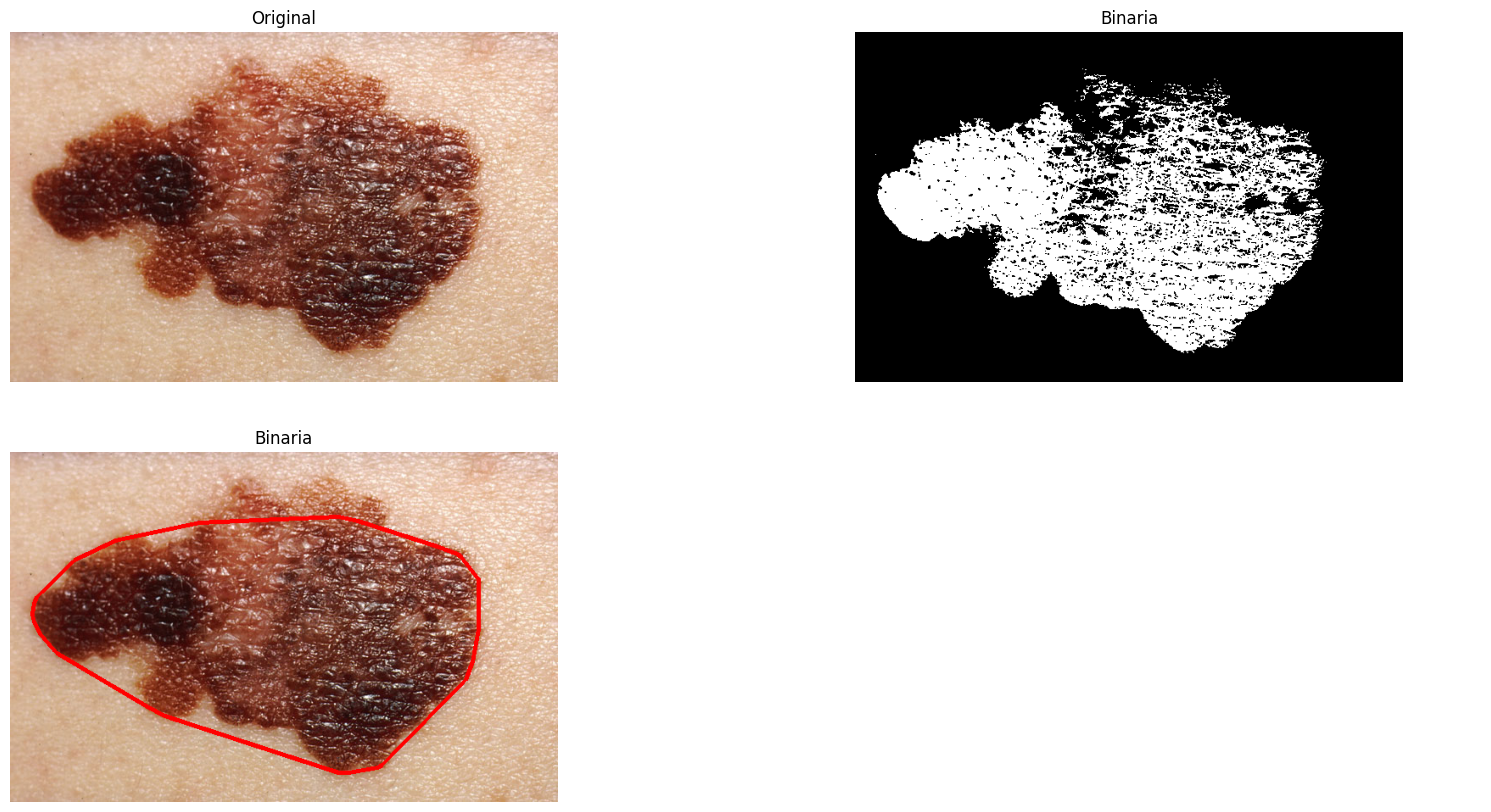

In [383]:
melanoma = cv2.imread("imagenes/Melanoma.jpg",cv2.IMREAD_COLOR_RGB)
_, melanoma_bin = cv2.threshold(cv2.cvtColor(melanoma, cv2.COLOR_RGB2GRAY),100,255,cv2.THRESH_BINARY_INV)

# encontrar puntos del contorno
contornos, _ = cv2.findContours(melanoma_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
puntos = max(contornos, key=cv2.contourArea)

# envoltura convexa
hull = cv2.convexHull(puntos)
melanoma_final = melanoma.copy()
cv2.drawContours(melanoma_final, [hull], -1, 255, thickness=3)

fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0,0].imshow(melanoma, cmap='gray'); ax[0,0].set_title("Original"); ax[0,0].axis('off')
ax[0,1].imshow(melanoma_bin, cmap='gray'); ax[0,1].set_title("Binaria"); ax[0,1].axis('off')
ax[1,0].imshow(melanoma_final, cmap='gray'); ax[1,0].set_title("Binaria"); ax[1,0].axis('off')
ax[1,1].axis('off')
plt.show()

# Ejercicio 6

Encuentre los esqueletos de los cuerpos presentes en la imagen. Alternativamente, puede aproximarlos mediante el afinamiento de las formas

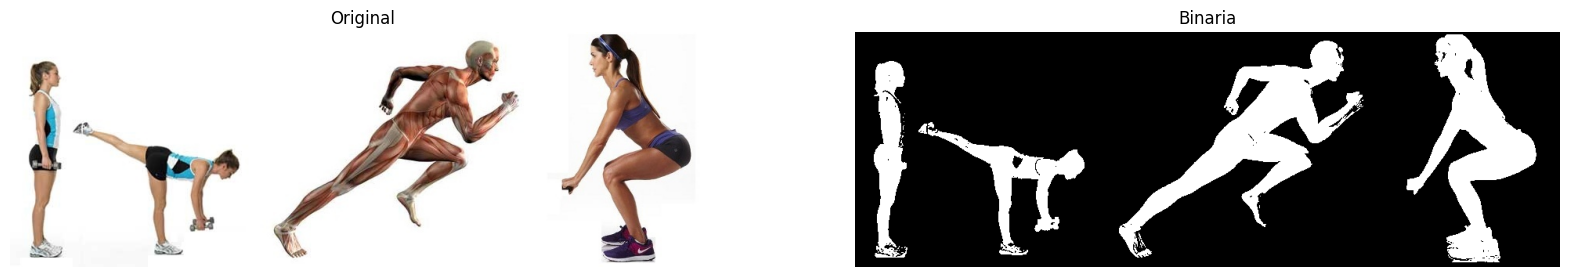

In [384]:
cuerpos = cv2.imread("imagenes/Cuerpos.jpg",cv2.IMREAD_COLOR_RGB)
_, cuerpos_bin = cv2.threshold(cv2.cvtColor(cuerpos, cv2.COLOR_RGB2GRAY), 200, 255, cv2.THRESH_BINARY_INV)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(cuerpos); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(cuerpos_bin, cmap='gray'); ax[1].set_title("Binaria"); ax[1].axis('off')
plt.show()

Para encontrar el esqueleto se calcula la apertura, se substrae de imagen, se suma el resultado al esqueleto y se vuelve a iterar con la apertura de la erosion original hasta que no haya pixeles que erosionar.

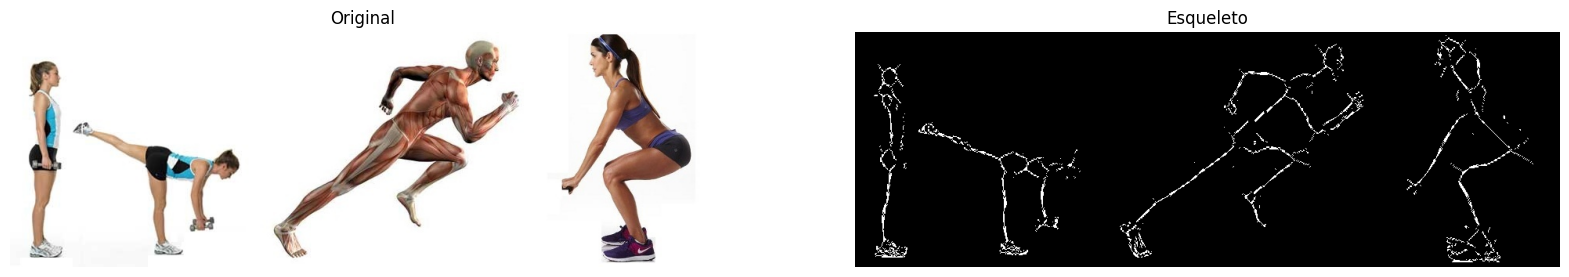

In [385]:
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))

esqueleto = np.zeros_like(cuerpos_bin, dtype=np.uint8)

temp_bin = cuerpos_bin.copy()
while True:
  erosion = cv2.erode(temp_bin, kernel)
  apertura = cv2.dilate(erosion, kernel)
  temp = cv2.subtract(temp_bin, apertura)
  esqueleto = cv2.bitwise_or(esqueleto, temp)
  temp_bin = erosion.copy()

  # condicion de corte
  if cv2.countNonZero(temp_bin) == 0:
    break

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(cuerpos, cmap='gray'); ax[0].set_title("Original"); ax[0].axis('off')
ax[1].imshow(esqueleto, cmap='gray'); ax[1].set_title("Esqueleto"); ax[1].axis('off')
plt.show()